# Does allele / peptide identity actually explain the variance in stability?

**The question.** `train_baseline.py` offers three split strategies — `random`, `allele`
(leave-HLA-out) and `cluster` (peptide-grouped). Grouped splits are only worth their cost
if group identity is a large share of what determines $t_{1/2}$. If most of the variance in
half-life lives *within* an allele (or within a peptide), then holding a group out removes
little information that the model couldn't have gotten elsewhere, and a random split is not
obviously leaky.

So: decompose $\mathrm{Var}(t_{1/2})$ into a between-group and a within-group part, once
grouping by allele and once grouping by peptide, and look at the distributions directly.

**On the scale.** Half-life is heavily right-skewed (median 1.1 h, max 256.7 h), so the plots
use a log x-axis. The variance decomposition is reported on the model's own target,
$s = 2^{-t_0/t_{1/2}}$ with $t_0 = 1$ h — that is the quantity the network actually fits,
so it's the one whose variance structure matters. $\log_{10} t_{1/2}$ is reported alongside
as a check that the conclusion isn't an artefact of the transform.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullFormatter

DATA = '../data/rasmussen_et_al_dataset - rasmussen_et_al_dataset.csv'
df = pd.read_csv(DATA)

# Model target: bounded stability score, t0 = 1 hour (Rasmussen et al. 2016).
t0 = 1.0
th = df['thalf_hours'].to_numpy(dtype=float)
df['score'] = np.where(th > 0, 2.0 ** (-t0 / np.maximum(th, 1e-9)), 0.0)

# Display-only: log axis cannot show the exact zeros, so floor them at half the
# smallest positive measurement. Affects the plots, never the statistics.
pos_min = th[th > 0].min()
df['thalf_plot'] = np.maximum(th, pos_min / 2)

print(f"{len(df):,} measurements | {df['allele'].nunique()} alleles | "
      f"{df['peptide'].nunique():,} peptides")
print(f"exact zeros: {(th == 0).sum():,} ({(th == 0).mean():.1%})  "
      f"floored to {pos_min/2:g} h for plotting only")
df[['allele', 'peptide', 'thalf_hours', 'score']].head()

28,166 measurements | 75 alleles | 5,633 peptides
exact zeros: 5,679 (20.2%)  floored to 0.025 h for plotting only


,allele,peptide,thalf_hours,score
0,HLA-A*02:01,VTTEVAFGL,1.8,0.680395
1,HLA-A*02:01,FVRQCFNPM,0.1,0.000977
2,HLA-A*02:01,FVRTLFQQM,0.1,0.000977
3,HLA-A*02:01,IPKRNRSIL,0.1,0.000977
4,HLA-A*02:01,QARQMVQAM,0.1,0.000977


## Plot 1 — half-life distribution per HLA allele

One row per allele, ordered by median half-life. The box spans the interquartile range with a
notch at the median; the thin whiskers are the 5th–95th percentiles. A dashed line marks the
global median, so the question "does this allele sit somewhere unusual?" is read against it.

If **between**-allele variance dominated, the boxes would march steadily upward and barely
overlap. If **within**-allele variance dominates, every box is wide and they all straddle the
global median.

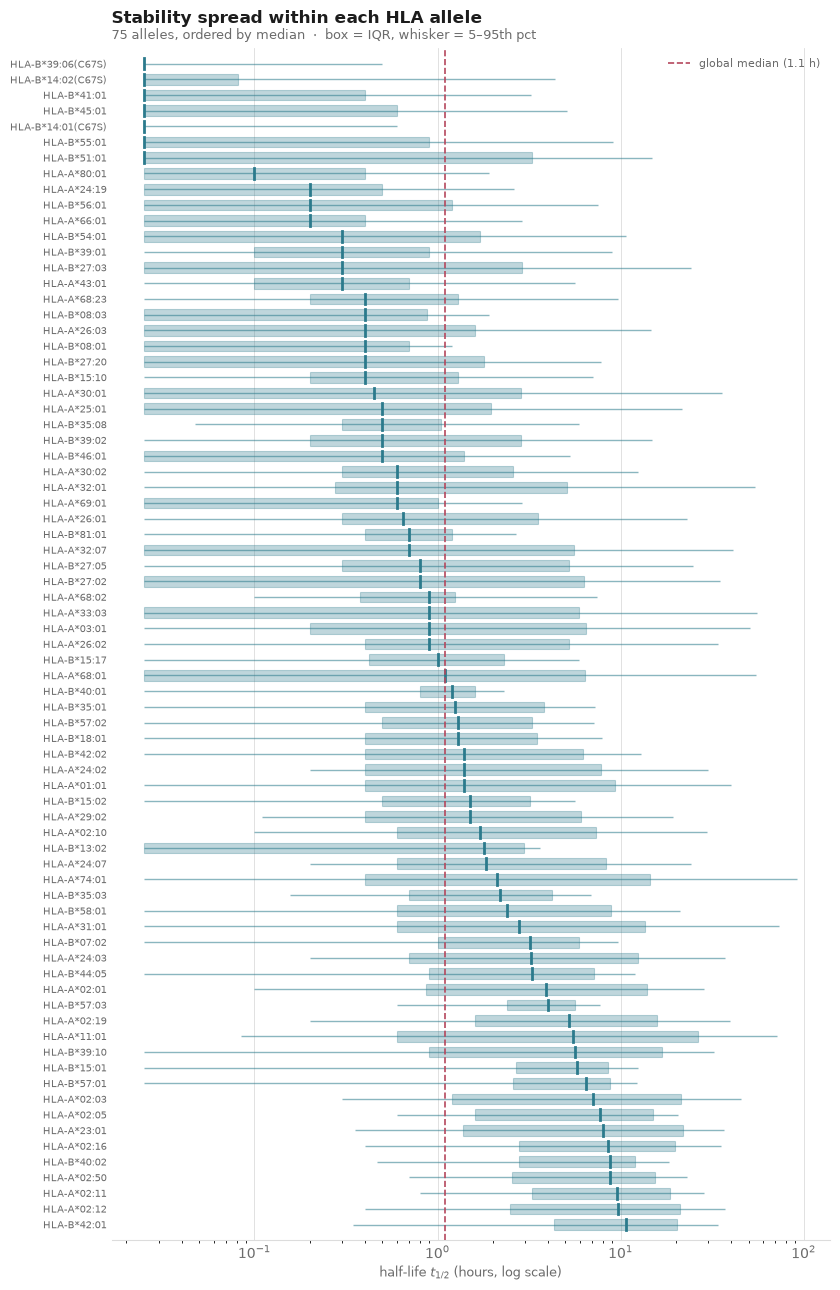

In [2]:
INK = '#1c1c1c'; MUTED = '#6b6b6b'; GRID = '#dcdcdc'
HUE  = '#2b7a8c'   # single sequential hue - magnitude, not identity
ACC  = '#b5485d'   # reference / annotation only


def group_box(ax, groups, order, value_col, labels=True, label_every=1):
    'Horizontal IQR boxes + 5-95 whiskers, one row per group.'
    for i, g in enumerate(order):
        v = groups.get_group(g)[value_col].to_numpy()
        q05, q25, q50, q75, q95 = np.percentile(v, [5, 25, 50, 75, 95])
        ax.plot([q05, q95], [i, i], color=HUE, lw=1.0, alpha=.55,
                solid_capstyle='butt', zorder=2)
        ax.add_patch(plt.Rectangle((q25, i - .34), q75 - q25, .68,
                                   facecolor=HUE, alpha=.30,
                                   edgecolor=HUE, lw=.8, zorder=3))
        ax.plot([q50, q50], [i - .34, i + .34], color=HUE, lw=2.0, zorder=4)
    ax.set_ylim(-1, len(order))
    ax.set_yticks(range(0, len(order), label_every))
    if labels:
        ax.set_yticklabels([order[i] for i in range(0, len(order), label_every)], fontsize=7)
    else:
        ax.set_yticklabels([])
    ax.invert_yaxis()


def style(ax, xlabel, title, subtitle):
    ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.grid(axis='x', color=GRID, lw=.6, zorder=0)
    ax.set_axisbelow(True)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=MUTED, length=0)
    ax.set_title(title, fontsize=12, color=INK, loc='left', pad=18, weight='bold')
    ax.text(0, 1.005, subtitle, transform=ax.transAxes, fontsize=9,
            color=MUTED, va='bottom')


by_allele = df.groupby('allele')
allele_order = by_allele['thalf_plot'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8.5, 13))
group_box(ax, by_allele, allele_order, 'thalf_plot')
gmed = df['thalf_hours'].median()
ax.axvline(gmed, color=ACC, ls='--', lw=1.2, zorder=5,
           label=f'global median ({gmed:g} h)')
ax.legend(frameon=False, fontsize=8, loc='upper right', labelcolor=MUTED)
style(ax, 'half-life $t_{1/2}$ (hours, log scale)',
      'Stability spread within each HLA allele',
      f'{len(allele_order)} alleles, ordered by median  ·  box = IQR, whisker = 5–95th pct')
plt.tight_layout(); plt.show()

## Plot 2 — the same, per peptide

Peptides are the other grouping axis, but the shape of the data is different: 5,633 unique
peptides with a **median of 4 measurements each**, versus ~368 per allele. Four points give a
useless IQR, so this plot restricts to peptides measured against at least 8 alleles and shows a
random sample of 75 of them — matched to the allele count so the two panels are read on the
same visual footing. The sample is seeded; the restriction is stated because it biases toward
well-characterised peptides.

1,237 of 5,633 peptides have >= 8 measurements; showing 75 at random (seed 0)


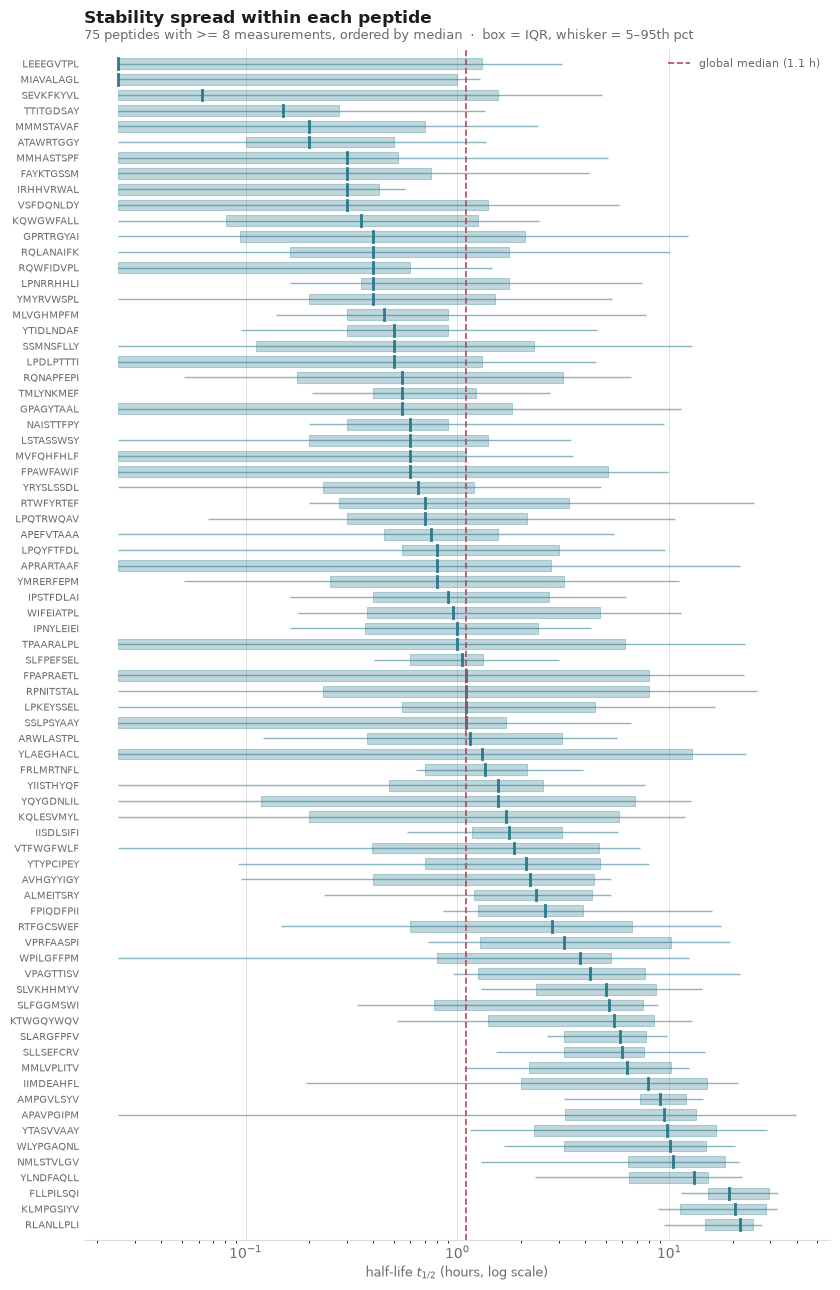

In [3]:
MIN_OBS, N_SHOW, SEED = 8, 75, 0

pep_counts = df['peptide'].value_counts()
eligible = pep_counts[pep_counts >= MIN_OBS].index
rng = np.random.default_rng(SEED)
shown = rng.choice(eligible, size=min(N_SHOW, len(eligible)), replace=False)

sub = df[df['peptide'].isin(shown)]
by_pep = sub.groupby('peptide')
pep_order = by_pep['thalf_plot'].median().sort_values().index.tolist()

print(f"{len(eligible):,} of {df['peptide'].nunique():,} peptides have >= {MIN_OBS} "
      f"measurements; showing {len(pep_order)} at random (seed {SEED})")

fig, ax = plt.subplots(figsize=(8.5, 13))
group_box(ax, by_pep, pep_order, 'thalf_plot')
ax.axvline(gmed, color=ACC, ls='--', lw=1.2, zorder=5,
           label=f'global median ({gmed:g} h)')
ax.legend(frameon=False, fontsize=8, loc='upper right', labelcolor=MUTED)
style(ax, 'half-life $t_{1/2}$ (hours, log scale)',
      'Stability spread within each peptide',
      f'{len(pep_order)} peptides with >= {MIN_OBS} measurements, ordered by median'
      '  ·  box = IQR, whisker = 5–95th pct')
plt.tight_layout(); plt.show()

## The number behind the picture — variance decomposition

Eyeballing box overlap is suggestive, not decisive. The matching statistic is the
**intraclass correlation** from a one-way random-effects model
$y_{ij} = \mu + a_i + \varepsilon_{ij}$:

$$\mathrm{ICC} = \frac{\sigma^2_{\text{between}}}{\sigma^2_{\text{between}} + \sigma^2_{\text{within}}}$$

read as *the fraction of total variance attributable to group identity*. Note this is **not**
the naive $\eta^2 = SS_B/SS_T$: with many small groups $\eta^2$ is badly inflated upward
(5,633 peptide groups can shatter 28k points almost for free), so the unbiased
components estimate is the one to trust. Both are printed so the gap is visible.

In [4]:
def variance_components(y, groups):
    'One-way random-effects decomposition. Returns ICC and the naive eta^2.'
    y = np.asarray(y, dtype=float)
    g = pd.Series(groups).to_numpy()
    N = len(y)
    _, inv, n_i = np.unique(g, return_inverse=True, return_counts=True)
    k = len(n_i)
    grand = y.mean()
    means = np.bincount(inv, weights=y) / n_i

    ss_b = float((n_i * (means - grand) ** 2).sum())
    ss_w = float(((y - means[inv]) ** 2).sum())
    ss_t = ss_b + ss_w

    ms_b, ms_w = ss_b / (k - 1), ss_w / (N - k)
    n0 = (N - (n_i ** 2).sum() / N) / (k - 1)          # effective group size
    var_b = max((ms_b - ms_w) / n0, 0.0)               # unbiased, floored at 0
    icc = var_b / (var_b + ms_w)
    return {'n_groups': k, 'median_group_n': int(np.median(n_i)),
            'icc': icc, 'eta2_naive': ss_b / ss_t,
            'var_between': var_b, 'var_within': ms_w}


rows = []
for target, label in [('score', 's = 2^(-1/t)'), (None, 'log10 t_half')]:
    y = df['score'] if target else np.log10(df['thalf_plot'])
    for col in ('allele', 'peptide'):
        r = variance_components(y, df[col]); r['target'] = label; r['grouping'] = col
        rows.append(r)

vc = pd.DataFrame(rows)[['target', 'grouping', 'n_groups', 'median_group_n',
                         'icc', 'eta2_naive', 'var_between', 'var_within']]
vc.style.format({'icc': '{:.3f}', 'eta2_naive': '{:.3f}',
                 'var_between': '{:.4f}', 'var_within': '{:.4f}'})

,target,grouping,n_groups,median_group_n,icc,eta2_naive,var_between,var_within
0,s = 2^(-1/t),allele,75,368,0.307,0.305,0.0449,0.1016
1,s = 2^(-1/t),peptide,5633,4,0.203,0.362,0.0296,0.1162
2,log10 t_half,allele,75,368,0.320,0.318,0.3150,0.6698
3,log10 t_half,peptide,5633,4,0.210,0.368,0.2060,0.7736


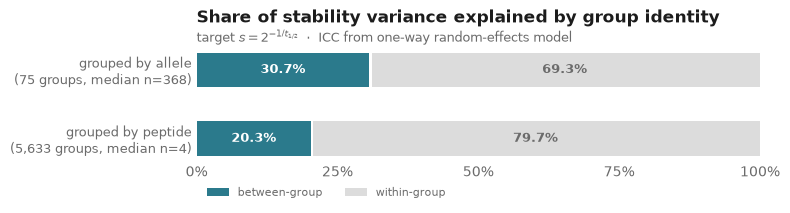

In [5]:
# Between vs within, as a share of total variance - on the model's own target.
m = vc[vc['target'] == 's = 2^(-1/t)'].set_index('grouping').loc[['allele', 'peptide']]

fig, ax = plt.subplots(figsize=(8, 2.6))
ypos = np.arange(len(m))
btw = m['icc'].to_numpy(); wth = 1 - btw
GAP = 0.004   # 2px-equivalent surface gap between adjoining fills

ax.barh(ypos, btw, height=.5, color=HUE, zorder=3, label='between-group')
ax.barh(ypos, wth - GAP, left=btw + GAP, height=.5, color=GRID, zorder=3,
        label='within-group')

for i, b in enumerate(btw):
    ax.text(b / 2, i, f'{b:.1%}', ha='center', va='center', fontsize=9,
            color='white', weight='bold', zorder=4)
    ax.text(b + (1 - b) / 2, i, f'{1-b:.1%}', ha='center', va='center',
            fontsize=9, color=MUTED, weight='bold', zorder=4)

ax.set_yticks(ypos)
ax.set_yticklabels([f"grouped by {g}\n({m.loc[g,'n_groups']:,} groups, "
                    f"median n={m.loc[g,'median_group_n']})" for g in m.index], fontsize=9)
ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.invert_yaxis()
for s in ('top', 'right', 'left', 'bottom'):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=MUTED, length=0)
ax.set_title('Share of stability variance explained by group identity', fontsize=12,
             color=INK, loc='left', pad=18, weight='bold')
ax.text(0, 1.02, 'target $s = 2^{-1/t_{1/2}}$  ·  ICC from one-way random-effects model',
        transform=ax.transAxes, fontsize=9, color=MUTED, va='bottom')
ax.legend(frameon=False, fontsize=8, ncol=2, loc='lower left',
          bbox_to_anchor=(0, -.42), labelcolor=MUTED)
plt.tight_layout(); plt.show()

## The leakage question, asked directly

Variance structure is one input, but it is not the thing a split actually controls. The
concrete risk a random split carries is **near-duplicate rows straddling the boundary**. That
is measurable without any modelling: do the split, then count how much of the test set has its
own peptide — or its own allele — already present in train.

In [6]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(df))
tr, te = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)
train, test = df.iloc[tr], df.iloc[te]

seen_pep = set(train['peptide']); seen_all = set(train['allele'])
pep_leak = test['peptide'].isin(seen_pep).mean()
all_leak = test['allele'].isin(seen_all).mean()

# Tighter: the exact (peptide, allele) pair is unique here, but a test row whose peptide
# was measured against a *neighbouring* allele is the real near-duplicate case.
print(f"random 80/20 split ({len(train):,} train / {len(test):,} test)")
print(f"  test rows whose peptide appears in train: {pep_leak:.1%}")
print(f"  test rows whose allele  appears in train: {all_leak:.1%}")
print(f"  mean train measurements per test peptide: "
      f"{train['peptide'].value_counts().reindex(test['peptide']).fillna(0).mean():.1f}")

random 80/20 split (22,532 train / 5,634 test)
  test rows whose peptide appears in train: 93.0%
  test rows whose allele  appears in train: 100.0%
  mean train measurements per test peptide: 6.0


## Reading the result

Three things to hold together:

1. **If the ICC bars are small**, group identity explains little of the variance. Most of what
   makes one measurement differ from another is the specific peptide–allele *pairing*, not a
   per-allele or per-peptide offset. A grouped split removes a group's mean, and if that mean
   carries little information, a grouped split is not removing much leakage — which is the
   argument for `random`.

2. **But the leakage count is the sharper test**, and it answers a different question. Even
   with a low ICC, if nearly every test peptide appears many times in train, the model can
   reach a test row through its near-neighbours rather than through learned chemistry. Low
   between-group variance does not make that overlap disappear.

3. **And neither statistic settles the `allele` split**, because leave-allele-out is not
   defending against leakage — it is measuring a *capability*. NetMHCstabpan's claim is that a
   34-residue pseudosequence lets it predict for alleles it has never seen, of which there are
   thousands in the population. The only split that tests that claim is one with zero shared
   alleles. A low allele ICC would actually make that test *harder to pass*, not unnecessary:
   it would mean allele identity is not a simple additive offset the model can shortcut, so
   generalising to a new allele requires genuinely modelling the groove.

So the honest framing: use `random` to measure interpolation, `cluster` to measure peptide
generalisation, `allele` to measure pan-specificity. Report all three. The spread between them
is the finding — a single number from any one of them is not.

A note on how this maps to the paper. Rasmussen et al. used **only** peptide-grouped splits:
the unique peptides were divided into five sets in a fivefold CV scheme, with all measurements
for a given peptide forced into the same fold ("in this way, no peptide can belong to more than
one group"). That is exact-identity grouping, which is what `cluster` at `train_baseline.py:404`
implements — so `cluster` is a faithful reproduction of the paper's partitioning, not a weakened
version of it. Neither `random` (the script's default) nor `allele` appears in the paper at all.

Two real deviations remain: the script does a single holdout rather than 5-fold CV (`KFold` is
imported at `train_baseline.py:25` but never used), and the paper's held-out fifth doubles as the
early-stopping set, whereas the script carves a separate 10% validation set out of train.